# Classificação de Imagens com Transfer Learning (MobileNetV2)
Nesta atividade prática será desenvolvido um modelo de **classificação de imagens** utilizando **Transfer Learning** com a arquitetura **MobileNetV2**.

A técnica de transfer learning reutiliza um modelo treinado em grandes bases (ex.: ImageNet) e o adapta para um novo problema.

Vantagens:
- Reduz tempo de treinamento
- Melhora desempenho
- Permite usar datasets menores

Nesta versão, a atividade é implementada com **PyTorch**, utilizando o pacote **torchvision** para carregar o dataset e o modelo MobileNetV2 pré-treinado.

## 1. Estrutura do Dataset
```
dataset/
   train/
      classe1/
      classe2/
   validation/
      classe1/
      classe2/
```
Cada pasta representa uma classe.

## 2. Instalação das bibliotecas
Execute no terminal:
`pip install torch torchvision opencv-python matplotlib scikit-learn`

In [ ]:
pip install torch torchvision opencv-python matplotlib scikit-learn

## 3. Baixando o Dataset (Kaggle)
Na primeira execução, pode ser necessário configurar sua chave de API do Kaggle (veja [aqui](https://www.kaggle.com/docs/api) como gerar o arquivo `kaggle.json`).

In [ ]:
import kagglehub

# Baixa a versão mais recente do dataset
path = kagglehub.dataset_download("utkarshsaxenadn/flower-classification-5-classes-roselilyetc")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flower-classification-5-classes-roselilyetc' dataset.
Path to dataset files: /kaggle/input/flower-classification-5-classes-roselilyetc


Antes de carregar o dataset, inspecione a estrutura de pastas baixada -- datasets do Kaggle nem sempre seguem o mesmo padrão, e é importante confirmar os nomes exatos das subpastas antes de apontar o ImageFolder para elas:

In [ ]:
import os

for raiz, pastas, arquivos in os.walk(path):
    nivel = raiz.replace(path, '').count(os.sep)
    indent = '  ' * nivel
    print(f"{indent}{os.path.basename(raiz)}/")
    if nivel < 2:
        for arq in arquivos[:3]:
            print(f"{indent}  {arq}")

flower-classification-5-classes-roselilyetc/
  Flower Classification V2/
    V2/
      Testing Data/
        Orchid/
        Aster/
        Lavender/
        Poppy/
        Marigold/
        Lily/
        Daisy/
        Sunflower/
        Rose/
        Iris/
      TFRecords/
        Valid/
        Test/
        Train/
      Training Data/
        Orchid/
        Aster/
        Lavender/
        Poppy/
        Marigold/
        Lily/
        Daisy/
        Sunflower/
        Rose/
        Iris/
      Validation Data/
        Orchid/
        Aster/
        Lavender/
        Poppy/
        Marigold/
        Lily/
        Daisy/
        Sunflower/
        Rose/
        Iris/
  Flower Classification/
    Flower Classification/
      Testing Data/
        Lavender/
        Lily/
        Daisy/
        Sunflower/
        Rose/
      Training Data/
        Lavender/
        Lily/
        Daisy/
        Sunflower/
        Rose/
      Validation Data/
        Lavender/
        Lily/
        Dais

Com a estrutura confirmada acima, ajuste a variável CLASSES_DIR abaixo para apontar exatamente para a pasta que contém as subpastas de cada classe (pode ser o próprio path, ou um subdiretório dentro dele -- depende do que a inspeção anterior mostrar):

In [ ]:
from pathlib import Path

root = Path(path)
candidatos = list(root.rglob("Training Data")) + list(root.rglob("train"))

print("Candidatos encontrados:")
for candidato in candidatos:
    print(candidato)

if not candidatos:
    raise FileNotFoundError("Não encontrei Training Data nem train")

CLASSES_DIR = str(candidatos[0])
print("CLASSES_DIR =", CLASSES_DIR)
print("Classes =", [p.name for p in Path(CLASSES_DIR).iterdir() if p.is_dir()])


Candidatos encontrados:
/kaggle/input/flower-classification-5-classes-roselilyetc/Flower Classification/Flower Classification/Training Data
/kaggle/input/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Training Data
CLASSES_DIR = /kaggle/input/flower-classification-5-classes-roselilyetc/Flower Classification/Flower Classification/Training Data
Classes = ['Lavender', 'Lily', 'Daisy', 'Sunflower', 'Rose']


## 4. Importando bibliotecas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt

## 5. Carregando o Dataset

In [ ]:
from pathlib import Path

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

root = Path(path)
train_dir = next(root.rglob("Training Data"))
val_dir = next(root.rglob("Validation Data"))

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("As classes de treino e validação são diferentes")

train_ds = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)
val_ds = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False
)

print("Classes:", train_dataset.classes)
print("Treino:", len(train_dataset), "Validação:", len(val_dataset))


Classes: ['Daisy', 'Lavender', 'Lily', 'Rose', 'Sunflower']
Treino: 5000 Validação: 2500


## 6. Pré-processamento das imagens

In [ ]:
from pathlib import Path

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

root = Path(path)
dataset_root = root / "Flower Classification" / "Flower Classification"

train_dir = dataset_root / "Training Data"
val_dir = dataset_root / "Validation Data"

if not train_dir.is_dir() or not val_dir.is_dir():
    raise FileNotFoundError(
        f"Pastas esperadas não encontradas:\n{train_dir}\n{val_dir}"
    )

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("As classes de treino e validação são diferentes")

train_ds = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_ds = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))


Classes: ['Daisy', 'Lavender', 'Lily', 'Rose', 'Sunflower']
Treino: 5000
Validação: 2500


## 7. Carregando MobileNetV2

In [ ]:
base_model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

## 8. Congelando camadas

In [ ]:
for param in base_model.parameters():
    param.requires_grad = False

print(type(train_dataset))
print(type(val_dataset))



<class 'torchvision.datasets.folder.ImageFolder'>
<class 'torchvision.datasets.folder.ImageFolder'>


## 9. Construindo classificador

In [ ]:
num_classes = len(train_dataset.classes)

base_model.classifier = nn.Sequential(
    nn.Linear(base_model.last_channel, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

model = base_model

## 10. Compilando modelo

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## 11. Treinamento

In [ ]:
epochs = 10
history = {'accuracy': [], 'val_accuracy': []}

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    for images, labels in train_ds:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_ds:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f'Época {epoch+1}/{epochs} - acurácia treino: {train_acc:.4f} - acurácia validação: {val_acc:.4f}')

Época 1/10 - acurácia treino: 0.8536 - acurácia validação: 0.9324
Época 2/10 - acurácia treino: 0.9188 - acurácia validação: 0.9368
Época 3/10 - acurácia treino: 0.9324 - acurácia validação: 0.9316
Época 4/10 - acurácia treino: 0.9344 - acurácia validação: 0.9252
Época 5/10 - acurácia treino: 0.9330 - acurácia validação: 0.9416
Época 6/10 - acurácia treino: 0.9398 - acurácia validação: 0.9272
Época 7/10 - acurácia treino: 0.9448 - acurácia validação: 0.9408
Época 8/10 - acurácia treino: 0.9500 - acurácia validação: 0.9320
Época 9/10 - acurácia treino: 0.9560 - acurácia validação: 0.9340
Época 10/10 - acurácia treino: 0.9548 - acurácia validação: 0.9292


Relatório no Testing Data:
              precision    recall  f1-score   support

       Daisy     0.9289    0.8538    0.8898       260
    Lavender     0.9737    0.9569    0.9652       116
        Lily     0.9133    0.9629    0.9374       350
        Rose     0.9886    0.8969    0.9405        97
   Sunflower     0.8514    0.9333    0.8905       135

    accuracy                         0.9217       958
   macro avg     0.9312    0.9208    0.9247       958
weighted avg     0.9237    0.9217    0.9216       958



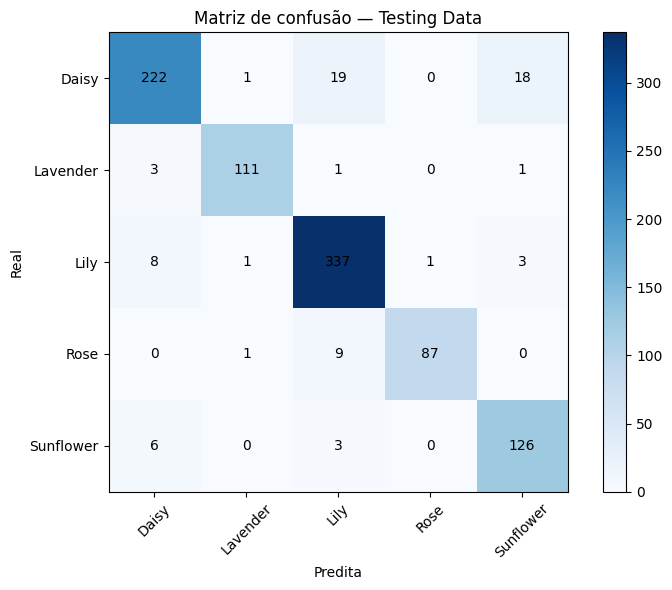

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

test_dir = dataset_root / "Testing Data"
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

if test_dataset.classes != train_dataset.classes:
    raise ValueError("A ordem das classes do teste é diferente da do treino")

test_ds = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False
)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_ds:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.cpu().numpy())

print("Relatório no Testing Data:")
print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusão - Testing Data")
plt.colorbar()
plt.xticks(np.arange(len(test_dataset.classes)), test_dataset.classes, rotation=45)
plt.yticks(np.arange(len(test_dataset.classes)), test_dataset.classes)
plt.xlabel("Predita")
plt.ylabel("Real")

for i in range(len(test_dataset.classes)):
    for j in range(len(test_dataset.classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()



Acurácia no conjunto de teste: 92,17%. F1-macro: 92,47%. Validação: 92,92%.

## 12. Avaliação

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_ds:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print('Acurácia:', accuracy)

Acurácia: 0.9292


## 13. Visualização do treinamento

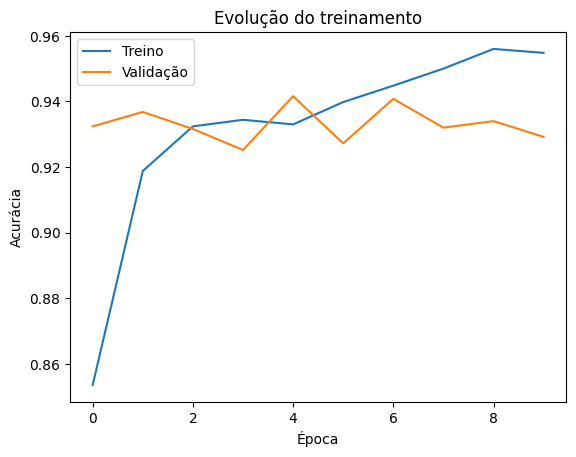

In [ ]:
plt.plot(history['accuracy'], label='Treino')
plt.plot(history['val_accuracy'], label='Validação')
plt.legend()
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução do treinamento')
plt.show()

## 14. Salvando o modelo

In [ ]:
torch.save(model.state_dict(), 'modelo_classificacao_mobilenet.pth')